# rust-knn vs scikit-learn: Measuring the speed of a Rust-backed KNN in Python

**rust-knn** is a k-nearest-neighbors classifier written in Rust and exposed to Python through PyO3. It offers a small API, familiar to users of scikit-learn:

- `fit` / `predict`, matching the scikit-learn estimator pattern
- a choice of distance metric (euclidean, manhattan, cosine)
- a choice of brute-force or KD-tree search

It installs from PyPI as an ordinary wheel and needs no C or C++ toolchain on the user's machine.

This notebook measures one thing carefully: how long `predict` takes, and how that compares to scikit-learn's `KNeighborsClassifier` across two axes, training-set size and dimensionality.

The short version: for small datasets, rust-knn is the fastest option here, several times quicker than scikit-learn. As the training set grows, or as dimensionality climbs, scikit-learn pulls ahead, because its distance computation runs through a vectorized, cache-blocked BLAS routine that rust-knn's current scalar loop does not yet match. Mapping where each one wins is the point of what follows.

### The 4 implementations

| Implementation | Why it behaves this way |
|---|---|
| **Rust brute-force** | Minimal per-call overhead; a tight scalar loop wins at small N, where the O(N) cost is cheap. |
| **Rust KD-tree** | O(log N) pruning wins at moderate N and low-to-moderate D, where tree traversal skips most distance computations. |
| **sklearn brute-force** | Euclidean distances run as a vectorized, cache-blocked BLAS matrix multiply, so the per-element constant is small enough to win at large N or high D. |
| **sklearn KD-tree** | A mature Cython KD-tree with the same asymptotics as Rust's; competitive at low D, degrades badly at high D. |

## Section 0: Configuration

*Environment, library versions, and benchmark settings, recorded so the run is reproducible.*

In [13]:
import os
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
import seaborn as sns

# Setting base project directory to ../src/
sys.path.insert(0, "../src")
from benchmark import run_single, run_scalability_sweep, run_dimensionality_sweep, rust_knn_version, run_real_datasets

# RELOAD = True  ==> Use existing CSV data in ../results/
# RELOAD = False ==> Benchmarks are re-run and data is repopulated.
RELOAD = True

# Benchmark parameters
SIZES = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000, 500_000]
DIMS = [2, 5, 10, 50, 100, 500]
DIM = 10          # fixed dim for scalability sweep
N_TRAIN = 50_000  # fixed n_train for dimensionality sweep
N_QUERIES = 500
K = 3
METRIC = "euclidean"
SEED = 42
RUNS = 7
WARMUP = 3

v = rust_knn_version()
n_threads = os.environ.get("RAYON_NUM_THREADS") or f"default ({os.cpu_count()} cores)"

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.precision", 4)

# Shared plot palette and table styler — defined once, reused across sections.
palette = {"rust": "#b7410e", "sklearn": "#00798c"}

def highlight_fastest(row):
    styles = [""] * len(row.index)
    fastest_col = row["fastest"]
    if fastest_col in row.index:
        styles[row.index.get_loc(fastest_col)] = "background-color: #c6efce; font-weight: bold"
    return styles

# Benchmark configuration
config = {
    "runs per measurement": RUNS,
    "warmup runs": WARMUP,
    "median reported": True,
    "threads": n_threads,
    "random seed": SEED,
    "k (neighbors)": K,
    "n_queries": N_QUERIES,
    "timer": "time.perf_counter()",
    "timed region": ".predict() only (.fit() excluded)",
}

print("Benchmark configuration:")
for key, val in config.items():
    print(f"  {key:<24} {val}")

print(f"\nHardware / Software:")
print(f"  {'Python:':<24} {platform.python_version()}")
# print(f"  {'OS:':<24} {platform.platform()}")
print(f"  {'CPU:':<24} {platform.processor() or 'unknown'}")
print(f"  {'rust-knn version:':<24} v{v}")

Benchmark configuration:
  runs per measurement     7
  warmup runs              3
  median reported          True
  threads                  default (8 cores)
  random seed              42
  k (neighbors)            3
  n_queries                500
  timer                    time.perf_counter()
  timed region             .predict() only (.fit() excluded)

Hardware / Software:
  Python:                  3.12.3
  CPU:                     x86_64
  rust-knn version:        v0.1.3


## Section 1: Correctness

Before timing anything, it's worth checking that both implementations make the same predictions. KNN predictions can differ for legitimate reasons: when two neighbors sit at the same distance, or two classes tie in the vote, different implementations break the tie differently but are both correct. So rather than demand identical output, the check here is for high agreement between implementations.

In [2]:
import knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

sk = KNeighborsClassifier(n_neighbors=3, algorithm="brute").fit(X_tr, y_tr)
ru = knn.KnnClassifier(3, metric=knn.Metric.Euclidean, algorithm=knn.Algorithm.BruteForce)
ru.fit(X_tr, y_tr)

sk_preds = sk.predict(X_te)
ru_preds = ru.predict(X_te)

print(f"sklearn: {sk_preds[:10].tolist()}")
print(f"rust:    {list(ru_preds[:10])}")

agree = np.mean(np.asarray(sk_preds) == np.asarray(ru_preds))
assert agree >= 0.99, f"only {agree:.2%} agreement on Iris"
print(f"Agreement on Iris (held-out test set): {agree:.2%}")

sklearn: [1, 0, 2, 1, 1, 0, 1, 2, 1, 1]
rust:    [1, 0, 2, 1, 1, 0, 1, 2, 1, 1]
Agreement on Iris (held-out test set): 100.00%


## Section 2: Scalability

**Question:** how does prediction time scale as the training set grows?

Dimensionality is fixed at D=10 and the training set grows from 1,000 to 500,000 points, with 500 queries timed against each implementation. On log-log axes the shape is easy to read: brute-force search is linear in N (a straight line of slope near 1), while KD-tree search grows much more slowly, since each query visits only a fraction of the tree. The question is where the lines cross.

In [3]:
s_data_path = f"../results/scalability_v{v}.csv"

if RELOAD:
    s_df = pd.read_csv(s_data_path)
else:
    s_df = run_scalability_sweep(
        dim=DIM, sizes=SIZES, n_queries=N_QUERIES, k=K,
        metric=METRIC, seed=SEED, runs=RUNS, warmup=WARMUP,
    )
    s_df.to_csv(s_data_path, index=False)

s_df

,n_train,dim,n_queries,k,metric,library,algorithm,median_s,error
0,1000,10,500,3,euclidean,rust,bruteforce,0.0011,NaN
1,1000,10,500,3,euclidean,rust,kdtree,0.0015,NaN
2,1000,10,500,3,euclidean,sklearn,bruteforce,0.0322,NaN
3,1000,10,500,3,euclidean,sklearn,kdtree,0.0045,NaN
4,5000,10,500,3,euclidean,rust,bruteforce,0.0025,NaN
5,5000,10,500,3,euclidean,rust,kdtree,0.0056,NaN
6,5000,10,500,3,euclidean,sklearn,bruteforce,0.0338,NaN
7,5000,10,500,3,euclidean,sklearn,kdtree,0.0114,NaN
8,10000,10,500,3,euclidean,rust,bruteforce,0.0049,NaN
9,10000,10,500,3,euclidean,rust,kdtree,0.0099,NaN


In [4]:
scal_wide = s_df.pivot_table(
    index="n_train",
    columns=["library", "algorithm"],
    values="median_s",
)
scal_wide.columns = [f"{lib}/{algo}" for lib, algo in scal_wide.columns]

# Compute numeric aggregates FIRST, before adding any string columns
fastest = scal_wide.idxmin(axis=1)
fastest_s = scal_wide.min(axis=1)
slowest_s = scal_wide.max(axis=1)

# Now add the string + derived columns
scal_wide["fastest"] = fastest
scal_wide["fastest_s"] = fastest_s
scal_wide["speedup_vs_slowest"] = slowest_s / fastest_s

display_cols = ["fastest", "fastest_s", "speedup_vs_slowest"] + [
    c for c in scal_wide.columns if c not in ("fastest", "fastest_s", "speedup_vs_slowest")
]
scal_table = scal_wide[display_cols]

scal_table.style.apply(highlight_fastest, axis=1).format(
    {c: "{:.4f}" for c in scal_table.columns if c.endswith("s") or "/" in c}
).format({"speedup_vs_slowest": "{:.1f}x"})

,fastest,fastest_s,speedup_vs_slowest,rust/bruteforce,rust/kdtree,sklearn/bruteforce,sklearn/kdtree
n_train,,,,,,,
1000,rust/bruteforce,0.001074,29.9x,0.001074,0.001487,0.032169,0.004503
5000,rust/bruteforce,0.002541,13.3x,0.002541,0.005591,0.033782,0.011415
10000,rust/bruteforce,0.004930,6.1x,0.004930,0.009933,0.030167,0.015819
50000,rust/kdtree,0.024368,1.5x,0.029471,0.024368,0.035675,0.027441
100000,sklearn/kdtree,0.037709,2.0x,0.075313,0.043677,0.038171,0.037709
200000,sklearn/bruteforce,0.058502,3.3x,0.195347,0.068220,0.058502,0.077835
500000,sklearn/bruteforce,0.123909,4.9x,0.606084,0.148050,0.123909,0.140056


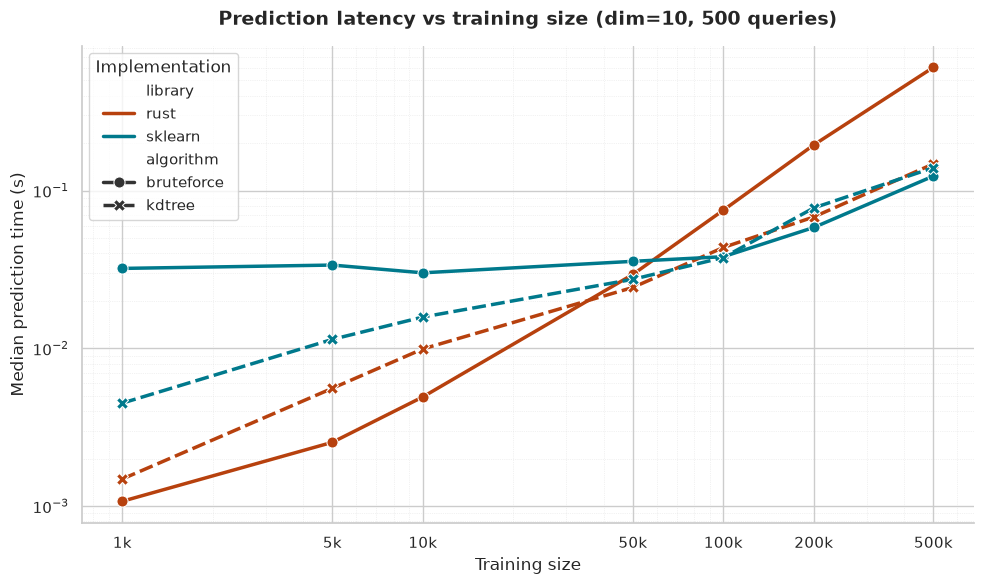

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=s_df,
    x="n_train",
    y="median_s",
    hue="library",
    style="algorithm",
    markers=True,
    dashes=True,
    palette=palette,
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

# Log-log with minor gridlines
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

# Force a labeled tick at every measured size — must come AFTER set_xscale
sizes = sorted(s_df["n_train"].unique())
ax.xaxis.set_major_locator(FixedLocator(sizes))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Larger fonts
ax.set_title("Prediction latency vs training size (dim=10, 500 queries)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Training size", fontsize=12)
ax.set_ylabel("Median prediction time (s)", fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, title_fontsize=12, title="Implementation")

plt.tight_layout()
fig.savefig(f"../results/scalability_v{v}.png", dpi=150, bbox_inches="tight")
plt.show()

### Takeaway

Three regimes show up as N grows, and the crossover lands between 50k and 100k.

**Small N (1k to 10k): Rust brute-force wins, by a lot.** At 1,000 points it predicts in about 1ms, roughly 4x faster than scikit-learn's best and nearly 30x faster than scikit-learn's own brute force. The distance work is cheap at these sizes, so per-call overhead is what matters, and rust's lean path carries almost none. Parallelism has little to chew on here, so most of the win is a tight implementation rather than threads.

**Moderate N (around 50k): Rust's KD-tree takes the lead, and the race tightens.** As N grows, brute-force's linear cost mounts and the KD-tree takes over, edging out scikit-learn's KD-tree by a slim margin (0.024s vs 0.027s). rust is still fastest here, but the comfortable small-N gap is gone.

**Large N (100k and up): scikit-learn pulls ahead, but not by much.** From 100k onward, scikit-learn takes the top spot, yet Rust's KD-tree shadows it closely the whole way: about 0.044s vs 0.038s at 100k, and 0.148s vs 0.124s at 500k, never more than roughly 1.2x behind. For a from-scratch library written in a few weeks, staying within twenty percent of a mature, BLAS-backed implementation across the largest datasets tested is the result I'm most happy with.

The one notable weakness is Rust brute-force at large N: roughly 5x slower than scikit-learn's brute force at 500k despite running on 8 threads. Same O(N) algorithm, same core count, very different speed. The difference is per-element efficiency: scikit-learn computes distances as a matrix multiplication through a vectorized, cache-blocked BLAS routine, while Rust's inner loop is scalar, and eight scalar threads still lose to vectorized ones. That gap is exactly what SIMD in the inner loop is meant to close, and it is the next step for the library.

These are uniform-data results, where the KD-tree's pruning is near its worst; Section 4 shows how real structure shifts the picture.

## Section 3: Dimensionality

**Question:** how does dimensionality erode the KD-tree's advantage?

Training size is fixed at N=50,000 and dimensionality varies from 2 to 500, again timing 500 queries. A KD-tree works by ruling out whole regions of space without checking them; as dimensionality climbs, that pruning gets less effective (the curse of dimensionality), and the tree degrades toward brute force while still paying for traversal.

One caveat: this sweep uses uniform random data, close to a worst case for KD-trees since there's no lower-dimensional structure to exploit. Real high-dimensional data often has such structure, where pruning keeps helping further out. Treat the high-D numbers as a floor, not the typical case.

In [6]:
d_data_path = f"../results/dimensionality_v{v}.csv"

if RELOAD:
    d_df = pd.read_csv(d_data_path)
else:
    d_df = run_dimensionality_sweep(
        n_train=N_TRAIN, dims=DIMS, n_queries=N_QUERIES, k=K,
        metric=METRIC, seed=SEED, runs=RUNS, warmup=WARMUP,
    )
    d_df.to_csv(d_data_path, index=False)

d_df

,n_train,dim,n_queries,k,metric,library,algorithm,median_s,error
0,50000,2,500,3,euclidean,rust,bruteforce,0.0157,NaN
1,50000,2,500,3,euclidean,rust,kdtree,0.0002,NaN
2,50000,2,500,3,euclidean,sklearn,bruteforce,0.0389,NaN
3,50000,2,500,3,euclidean,sklearn,kdtree,0.0010,NaN
4,50000,5,500,3,euclidean,rust,bruteforce,0.0202,NaN
5,50000,5,500,3,euclidean,rust,kdtree,0.0011,NaN
6,50000,5,500,3,euclidean,sklearn,bruteforce,0.0343,NaN
7,50000,5,500,3,euclidean,sklearn,kdtree,0.0029,NaN
8,50000,10,500,3,euclidean,rust,bruteforce,0.0274,NaN
9,50000,10,500,3,euclidean,rust,kdtree,0.0237,NaN


In [7]:
dim_wide = d_df.pivot_table(
    index="dim",
    columns=["library", "algorithm"],
    values="median_s",
)
dim_wide.columns = [f"{lib}/{algo}" for lib, algo in dim_wide.columns]

fastest = dim_wide.idxmin(axis=1)
fastest_s = dim_wide.min(axis=1)
slowest_s = dim_wide.max(axis=1)

dim_wide["fastest"] = fastest
dim_wide["fastest_s"] = fastest_s
dim_wide["speedup_vs_slowest"] = slowest_s / fastest_s

display_cols = ["fastest", "fastest_s", "speedup_vs_slowest"] + [
    c for c in dim_wide.columns if c not in ("fastest", "fastest_s", "speedup_vs_slowest")
]
dim_table = dim_wide[display_cols]

dim_table.style.apply(highlight_fastest, axis=1).format(
    {c: "{:.4f}" for c in dim_table.columns if c.endswith("s") or "/" in c}
).format({"speedup_vs_slowest": "{:.1f}x"})

,fastest,fastest_s,speedup_vs_slowest,rust/bruteforce,rust/kdtree,sklearn/bruteforce,sklearn/kdtree
dim,,,,,,,
2,rust/kdtree,0.000214,181.3x,0.015689,0.000214,0.038859,0.000979
5,rust/kdtree,0.001073,32.0x,0.020207,0.001073,0.034345,0.002861
10,rust/kdtree,0.023728,1.4x,0.027401,0.023728,0.032482,0.027326
50,sklearn/bruteforce,0.039516,41.8x,0.136442,0.461244,0.039516,1.653185
100,sklearn/bruteforce,0.055678,70.1x,0.305735,0.863543,0.055678,3.905360
500,sklearn/bruteforce,0.134779,94.8x,1.613070,2.675671,0.134779,12.779403


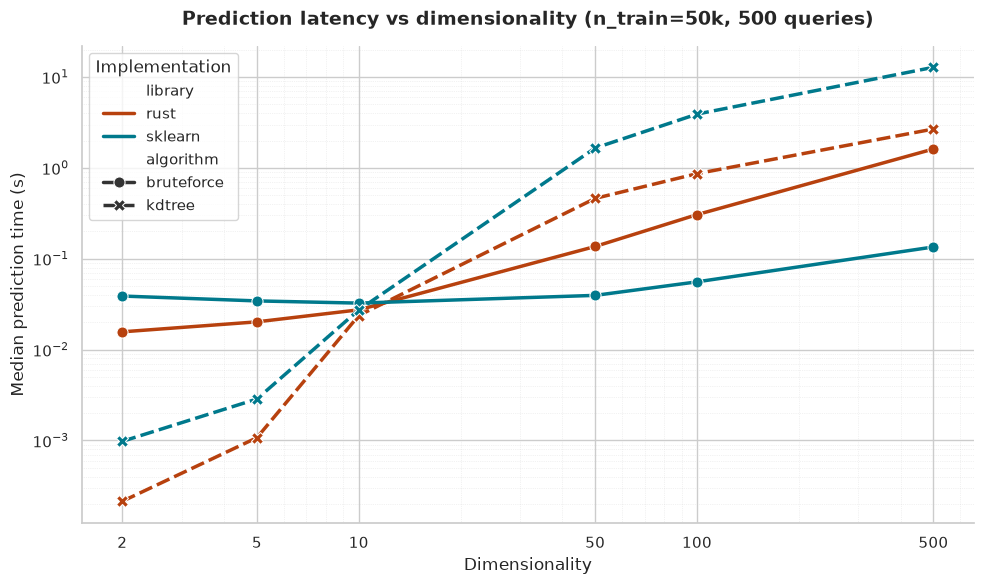

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=d_df,
    x="dim",
    y="median_s",
    hue="library",
    style="algorithm",
    markers=True,
    dashes=True,
    palette=palette,
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

# Label every measured dimensionality — dims are small integers, no /1000 needed
dims = sorted(d_df["dim"].unique())
ax.xaxis.set_major_locator(FixedLocator(dims))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: str(int(x))))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Prediction latency vs dimensionality (n_train=50k, 500 queries)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Dimensionality", fontsize=12)
ax.set_ylabel("Median prediction time (s)", fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, title_fontsize=12, title="Implementation")

plt.tight_layout()
fig.savefig(f"../results/dimensionality_v{v}.png", dpi=150, bbox_inches="tight")
plt.show()

### Takeaway

The dimensionality picture mirrors the size picture, with the crossover happening in D instead of N.

**Low D (2 to 5): Rust's KD-tree dominates.** At D=2 it predicts in about 0.2ms, on the order of 70x faster than Rust's own brute-force and ~180x faster than the slowest option. Pruning rules out almost all of the distance work, and this is exactly the regime KD-trees are built for.

**D=10: the advantage narrows sharply.** Rust's KD-tree still wins, but the margin collapses to a near-tie with both scikit-learn variants (0.024s vs 0.027s vs 0.032s). Pruning is starting to lose its grip.

**High D (50 and up): brute-force wins and the KD-trees fall apart.** Once pruning stops working, a KD-tree behaves like brute force but still pays for tree traversal, so it ends up slower than a plain scan. scikit-learn's brute force is the steadiest option here, since a vectorized distance computation is largely insensitive to dimension. Its own KD-tree shows the cost of the wrong tool: about 12.8s at D=500, roughly 95x slower than scikit-learn's brute force.

Worth noting at high D: Rust's KD-tree holds up far better than scikit-learn's, roughly 2.7s vs 12.8s at D=500. Neither is the right choice out there, but it shows the Rust tree isn't doing anything pathological as pruning breaks down.

A KD-tree only helps when dimensionality is low enough for pruning to actually rule things out. Past that, a vectorized brute-force scan is the better tool, whichever library it comes from.

## Section 4: Real data

The synthetic sweeps map out where each implementation wins as N and D vary independently. Real datasets are the test of whether that map holds when the data has actual structure: correlated features, uneven density, and intrinsic dimensionality lower than the raw feature count. The five datasets below were chosen to span the regimes the sweeps identified, not to stack a contest, so each one lands somewhere different on the N and D axes.

| Dataset | N (train) | D | Regime |
|---|---|---|---|
| breast_cancer | 69 | 30 | small N, moderate D |
| digits | 1,297 | 64 | small N, high D |
| California Housing | 20,140 | 8 | moderate N, low D |
| MNIST | 69,500 | 784 | high D |
| covertype | 580,512 | 54 | large N |

Each is timed with the same protocol as the sweeps (median of 7 runs, 3 warmup, 500 queries), and every implementation is checked for agreement against scikit-learn before its timing is reported. California Housing is a regression dataset, so its continuous target is binned into five quantile classes to make it a classification task; features are standardized, with the scaler fit on the training split only.

In [11]:
r_data_path = f"../results/real_v{v}.csv"

if RELOAD:
    r_df = pd.read_csv(r_data_path)
else:
    r_df = run_real_datasets(
        n_queries=N_QUERIES, k=K, metric=METRIC, runs=RUNS, warmup=WARMUP,
    )
    r_df.to_csv(r_data_path, index=False)

r_df

,n_train,dim,n_queries,k,metric,library,algorithm,median_s,error,dataset
0,69,30,500,3,euclidean,rust,bruteforce,0.0003,NaN,breast_cancer
1,69,30,500,3,euclidean,rust,kdtree,0.0006,NaN,breast_cancer
2,69,30,500,3,euclidean,sklearn,bruteforce,0.0193,NaN,breast_cancer
3,69,30,500,3,euclidean,sklearn,kdtree,0.0010,NaN,breast_cancer
4,1297,64,500,3,euclidean,rust,bruteforce,0.0028,NaN,digits
5,1297,64,500,3,euclidean,rust,kdtree,0.0039,NaN,digits
6,1297,64,500,3,euclidean,sklearn,bruteforce,0.0284,NaN,digits
7,1297,64,500,3,euclidean,sklearn,kdtree,0.0190,NaN,digits
8,20140,8,500,3,euclidean,rust,bruteforce,0.0082,NaN,california_housing
9,20140,8,500,3,euclidean,rust,kdtree,0.0048,NaN,california_housing


In [10]:
real_wide = r_df.pivot_table(
    index="dataset",
    columns=["library", "algorithm"],
    values="median_s",
)
real_wide.columns = [f"{lib}/{algo}" for lib, algo in real_wide.columns]

fastest = real_wide.idxmin(axis=1)
fastest_s = real_wide.min(axis=1)
slowest_s = real_wide.max(axis=1)

real_wide["fastest"] = fastest
real_wide["fastest_s"] = fastest_s
real_wide["speedup_vs_slowest"] = slowest_s / fastest_s

display_cols = ["fastest", "fastest_s", "speedup_vs_slowest"] + [
    c for c in real_wide.columns if c not in ("fastest", "fastest_s", "speedup_vs_slowest")
]
real_table = real_wide[display_cols]

real_table.style.apply(highlight_fastest, axis=1).format(
    {c: "{:.4f}" for c in real_table.columns if c.endswith("s") or "/" in c}
).format({"speedup_vs_slowest": "{:.1f}x"})

,fastest,fastest_s,speedup_vs_slowest,rust/bruteforce,rust/kdtree,sklearn/bruteforce,sklearn/kdtree
dataset,,,,,,,
breast_cancer,rust/bruteforce,0.000286,67.4x,0.000286,0.000575,0.019283,0.001033
california_housing,sklearn/kdtree,0.001382,20.5x,0.008178,0.004803,0.028400,0.001382
covertype,sklearn/kdtree,0.016678,123.8x,2.065257,0.497412,0.215218,0.016678
digits,rust/bruteforce,0.002761,10.3x,0.002761,0.003861,0.028443,0.018996
mnist,sklearn/bruteforce,0.250551,78.6x,3.163071,3.730318,0.250551,19.698903


**Takeaway**

**Small N: rust-knn wins.** On breast_cancer (69 training points) and digits (1,297), rust-knn is the fastest option, 3x faster than scikit-learn's best on breast_cancer and nearly 7x faster on digits. Both sit where Section 2 showed rust ahead: too little data for scikit-learn's vectorized kernels to amortize their overhead, so rust's lean predict path wins outright. Note this holds despite both datasets being moderate-to-high dimensional (30 and 64 features), at small N, the size effect dominates the dimensionality effect.

**Larger N: scikit-learn's KD-tree wins, and the reason is instructive.** On california_housing (20k points, 8 features) scikit-learn's KD-tree predicts in 0.0014s, about 3x faster than rust-knn's KD-tree. This is the one case worth dwelling on, because it's lower in both N and D than points where rust led on synthetic data, yet rust lost. The explanation is pruning quality: at 8 dimensions with real structure, a KD-tree query barely depends on training size (scikit-learn's time here is close to its time on the 69-point breast_cancer set), the signature of pruning that is working extremely well. Uniform synthetic data, used in the sweeps, is close to a worst case for pruning; real low-dimensional data is close to a best case. On data this easy to prune, scikit-learn's years of Cython tuning show.

**Large N or high D: scikit-learn wins by a wide margin.** On covertype (580k points) scikit-learn's KD-tree is ~30x faster than rust-knn's, and on MNIST (784 dimensions) scikit-learn's brute force is ~13x faster than rust-knn's. These are the regimes Sections 2 and 3 already flagged as scikit-learn's: large N where its vectorized distance kernel dominates, and high D where rust-knn's scalar brute-force loop pays the full price of every dimension. The MNIST brute-force gap (~13x) is wider than the synthetic large-N gap (~5x) for exactly this reason, vectorization helps more as dimensionality grows, which is the clearest argument for adding SIMD.

One bright spot in the hardest regime: on MNIST, rust-knn's KD-tree (3.7s) holds up far better than scikit-learn's (19.7s), the same graceful high-D degradation seen in the synthetic sweep. Neither is the right tool at 784 dimensions, but rust-knn's tree doesn't fall apart the way scikit-learn's does.

## Section 5: Methodology

Single timings are noisy. Garbage collection, OS scheduling, cache state, and CPU frequency scaling can all move a measurement by a large fraction, so every number here is a median over repeated runs after a warmup.

**Measurement protocol:**
- 7 measured runs per configuration, median reported (robust to outliers)
- 3 warmup runs discarded before measuring (stabilize caches and CPU frequency)
- Fixed random seed, so only the implementation varies, not the data
- `time.perf_counter()` for timing: monotonic and high-resolution, unlike `time.time()`
- Only `predict` is timed; `fit` is excluded
- Synthetic uniform [0,1) data, so N and D can be varied independently
- Threads left at the rayon default (8 cores on this machine), the configuration a user gets out of the box

Because each configuration uses one fixed dataset, the median captures timing noise, not variation across different random datasets.

**What this doesn't measure:**
- Training time, which is a separate question and is often amortized across many predictions (it's also where the KD-tree's build cost lives)
- Memory usage; latency is the focus here
- Accuracy beyond the correctness check, since predictions are validated against scikit-learn rather than scored

**Hardware:** results come from the machine printed above. The absolute numbers won't transfer to other hardware, but the curve shapes and crossover points should.

## Section 6: Takeaways

Two axes decide the winner, training-set size and dimensionality, and the picture is consistent across synthetic sweeps and real datasets.

**When rust-knn is the right call:**
- Small datasets. This is rust-knn's clearest win: on the smallest real sets it was several times faster than scikit-learn's best, and the synthetic sweep showed the same at a few thousand points. With little data, scikit-learn's vectorized kernels can't amortize their overhead, and rust-knn's lean predict path wins outright.
- When you want that speed without a C or C++ build step: it installs from PyPI as an ordinary wheel behind a familiar API.

**When scikit-learn is the better call:**
- Larger datasets with real low-dimensional structure, where its mature, heavily tuned KD-tree prunes extremely well; it took the moderate-N real dataset by ~3x even at only 8 dimensions.
- Very large training sets, where its vectorized, cache-blocked distance kernel outpaces rust-knn's scalar loop.
- High-dimensional data, where KD-tree pruning stops helping and a vectorized brute-force scan wins.

**The underlying tradeoff** is algorithmic advantage versus the constant factor. A KD-tree wins when its better Big-O outweighs scikit-learn's smaller per-element constant; scikit-learn wins when its vectorized distance routine shrinks that constant enough that Big-O stops mattering, or when its tree is simply better tuned for the data. rust-knn's brute-force path shares scikit-learn's complexity but not its vectorization, which is why it trails at large N today. SIMD in that inner loop is the next step, and the real-data results point at where it matters most: the high-dimensional brute-force gap was wider than the synthetic one, because vectorization pays off more as dimensionality grows.

One thing rust-knn already does well in the hardest regime: at very high dimensionality its KD-tree degrades far more gracefully than scikit-learn's, staying several times faster even where neither is the right tool. The implementation is sound; what's missing is the vectorized inner loop, and that's a known, scoped next step rather than a design problem.

**Practical recommendation:** reach for rust-knn on small datasets where you want speed with a pip install and no build step; use scikit-learn for larger or high-dimensional data, where its tuned KD-tree and vectorized kernels lead. As a general rule, avoid KD-trees once dimensionality is high, whichever library they come from.